In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
from scipy.optimize import curve_fit
from scipy.optimize import minimize
from scipy.ndimage import gaussian_filter
from matplotlib.gridspec import GridSpec



In [2]:
df = pd.read_csv('PhaseScan_data.csv').sample(frac = 1)
print(df.columns)

# feature : whether the sample is phase separated or not
# Proteil_Dil : dilute phase G3BP1 concentraiton in uM
# Protein : total G3BP1 concentration in uM
# RNA: total RNA concentraiton in ng/ul
# Suramin: total suramin concentration in uM

Index(['feature', 'Protein_Dil', 'Protein', 'RNA', 'Suramin'], dtype='object')


In [3]:
# Function definition to extract phase boundary from data
# Based on phase separation probability

def phase_boundary(df, xcol, ycol, f_col,
                   bins=80, boundary_range=(0.4, 0.6),
                   smooth_sigma=1.0, cmap='coolwarm',
                   plot=True, contour=False,
                   slab_col=None, slab_val=None,     #surmain concentration slab
                   slab_thickness=None):
    

    # Filter slab if specified 
    if slab_col is not None and slab_val is not None and slab_thickness is not None:
        section = df[(df[slab_col] >= slab_val) &
                     (df[slab_col] < slab_val + slab_thickness)]
    else:
        section = df.copy()

    # Separate by phase classification 
    df_sep = section[section[f_col] == True]     # phase separated state
    df_dil = section[section[f_col] == False]    # homogeneous state

    # Compute histograms 
    H_sep, xedges, yedges = np.histogram2d(df_sep[xcol], df_sep[ycol], bins=bins)
    H_dil, _, _ = np.histogram2d(df_dil[xcol], df_dil[ycol], bins=[xedges, yedges])

    # Smooth histograms by Gaussian filter
    if smooth_sigma > 0:
        H_sep = gaussian_filter(H_sep, sigma=smooth_sigma, mode='reflect')
        H_dil = gaussian_filter(H_dil, sigma=smooth_sigma, mode='reflect')

    # Probability field
    H_total = H_sep + H_dil
    with np.errstate(invalid='ignore', divide='ignore'):
        P_sep = np.where(H_total > 0, H_sep / H_total, np.nan)

    # Grid coordinates (bin centers)
    xcenters = (xedges[:-1] + xedges[1:]) / 2
    ycenters = (yedges[:-1] + yedges[1:]) / 2
    Xc, Yc = np.meshgrid(xcenters, ycenters, indexing="ij")

    # Boundary extraction
    boundary_mask = (P_sep >= boundary_range[0]) & (P_sep <= boundary_range[1])
    boundary_points = np.vstack([Xc[boundary_mask], Yc[boundary_mask]]).T


    # Plot if called
    if plot:
        plt.figure(figsize=(6, 5))
        plt.pcolormesh(xedges, yedges, P_sep.T, cmap=cmap, shading='auto')
        plt.scatter(boundary_points[:, 0], boundary_points[:, 1],
                    color='k', s=8, label=f'Boundary {boundary_range}')
        plt.colorbar(label='$P_{sep}$')
        plt.xlabel(xcol)
        plt.ylabel(ycol)

        title = f"Phase Boundary on {xcol}–{ycol} plane"
        if slab_col is not None:
            title += f"\n{slab_col} = {slab_val}–{slab_val + slab_thickness}"
        plt.title(title)
        plt.legend(frameon=False)
        plt.tight_layout()
        plt.show()

    # Return results
    return {"boundary_points": boundary_points,
            "Xc": Xc, "Yc": Yc,
            "P_sep": P_sep,
            "xedges": xedges, "yedges": yedges,
            "section": section
           }


In [4]:
# Definition of functions for global fitting


# ---------------------
# Phase Boundary Model
# ---------------------
def model(x, s, b, c, p):
    return s * x**(-b) * np.exp(c * x * np.exp(-p * x))


# ==============================================================
# Global Hill-coupled model (RNA-controlled)
# c = c0 * theta(R), p = p0 * theta(R)
# theta(R) = 1 / (1 + (R/KD)^n)
# ==============================================================
def model_global(X, KD, n, c0, p0, *slab_params):
    x = np.asarray(X[0], dtype=float)
    slab_idx = np.asarray(X[1], dtype=int)

    needed = 2 * (np.max(slab_idx) + 1)
    if len(slab_params) < needed:
        raise ValueError(
            f"Need {needed} slab params (s,b for each slab), got {len(slab_params)}. "
            f"len(popt) should be 4 + 2*nslabs (or at least 4 + 2*(max slab used + 1))."
        )

    s_arr = np.array(slab_params[0::2], dtype=float)
    b_arr = np.array(slab_params[1::2], dtype=float)

    R = slab_values[slab_idx]
    KD = max(float(KD), 1e-15)
    n  = max(float(n), 1e-12)

    theta = 1.0 / (1.0 + (R / KD)**n)
    c = c0 * theta
    p = p0 * theta

    s = s_arr[slab_idx]
    b = b_arr[slab_idx]

    return model(x, s, b, c, p)


# Function to plot phase boundary uncertainty envelope 
def get_fit_and_envelope(i, xx, popt, perr, model_global, lower=None, upper=None):
    X_plot = np.vstack([xx, np.full_like(xx, i, dtype=float)])
    y_fit = model_global(X_plot, *popt)

    y_iter = []
    base = np.array(popt, dtype=float)
    sig  = np.array(perr, dtype=float)

    # assumes parameter order:
    # [K_D, n, c_0, p_0, s0, b0, s1, b1, ...]
    idx_s = 4 + 2*i
    idx_b = 4 + 2*i + 1

    for dKS in (-0.1, +0.1):
        for dn in (-0.1, +0.1):
            for dc0 in (-0.1, +0.1):
                for dp0 in (-0.1, +0.1):
                    for ds in (-0.1, +0.1):
                        for db in (-0.1, +0.1):
                            params = base.copy()
                            params[0] += dKS * sig[0]
                            params[1] += dn  * sig[1]
                            params[2] += dc0 * sig[2]
                            params[3] += dp0 * sig[3]
                            params[idx_s] += ds * sig[idx_s]
                            params[idx_b] += db * sig[idx_b]

                            if lower is not None:
                                params = np.maximum(params, np.array(lower))
                            if upper is not None:
                                params = np.minimum(params, np.array(upper))

                            y_iter.append(model_global(X_plot, *params))

    y_hi = np.max(y_iter, axis=0)
    y_lo = np.min(y_iter, axis=0)
    return X_plot, y_fit, y_lo, y_hi


In [5]:
# -----------
# Slab setup
# -----------
slab_col = "RNA"
slab_values = np.array([20.0, 40.0, 60.0, 80.0, 100.0, 120.0], dtype=float)
slab_thickness = 10.0
nslabs = len(slab_values)
names = [f"{val:.0f} ng/µl" for val in slab_values]

# initiation for data number count
ndata_total = np.zeros(nslabs, dtype=int)     # total scatter points in section
ndata_dil   = np.zeros(nslabs, dtype=int)     # label==0
ndata_den   = np.zeros(nslabs, dtype=int)     # label==1
bcount_raw  = np.zeros(nslabs, dtype=int)     # boundary points extracted
bcount_fit  = np.zeros(nslabs, dtype=int)     # boundary points after maskextracted



# ----------------------------------
# Extract boundaries + COUNT DATA
# ----------------------------------
COORS = []
SECTIONS = []

for i, slab_val in enumerate(slab_values):
    result = phase_boundary( df=df, xcol='Suramin', ycol='Protein', f_col='feature',
        slab_col=slab_col, slab_val=float(slab_val), slab_thickness=slab_thickness,
        bins=60, boundary_range=(0.4, 0.6), smooth_sigma=1.0,
        plot=False, contour=False
          )

    section = result["section"]
    SECTIONS.append(section)
    
    # --- count total data in this slab ---
    label = section["feature"].values.astype(int)
    dil = section[label == 0]
    den = section[label == 1]

    ndata_dil[i] = len(dil)
    ndata_den[i] = len(den)
    ndata_total[i] = len(section)   


    # boundary extraction
    boundary = result["boundary_points"]
    x_data, y_data = boundary[:, 0], boundary[:, 1]
    mask = (x_data > 1e-6) & np.isfinite(x_data) & np.isfinite(y_data)
    x_m, y_m = x_data[mask], y_data[mask]
    COORS.append([x_m, y_m])
    bcount_raw[i] = len(x_m)

    # boundary points used for fitting 
    # drop outlier points
    mfit = (y_m < 4) & (x_m < 7)
    bcount_fit[i] = int(np.sum(mfit))


# --------------------------------------------------
# Build ONE concatenated dataset for global fitting
# --------------------------------------------------
x_all, y_all, idx_all = [], [], []
for i, (x_i, y_i) in enumerate(COORS):
    m = (y_i < 4) & (x_i < 7)
    x_i2 = x_i[m]
    y_i2 = y_i[m]
    if len(x_i2) == 0:
        continue
    x_all.append(x_i2)
    y_all.append(y_i2)
    idx_all.append(np.full_like(x_i2, i, dtype=int))

x_all = np.concatenate(x_all) if len(x_all) else np.array([], dtype=float)
y_all = np.concatenate(y_all) if len(y_all) else np.array([], dtype=float)
idx_all = np.concatenate(idx_all) if len(idx_all) else np.array([], dtype=int)

if len(x_all) == 0:
    raise RuntimeError("No boundary points survived the (y<4)&(x<7) mask across all slabs.")

X_all = np.vstack([x_all, idx_all.astype(float)])  


# --------------------------------------------------------------
# print data number counts
# --------------------------------------------------------------
print("\n=== Data Number Counts Per RNA Slab ===")
for i in range(nslabs):
    print(
        f"[RNA] = {names[i]}: "
        f"N = {ndata_total[i]} (dil={ndata_dil[i]}, den={ndata_den[i]}), "
        f"B = {bcount_fit[i]}/{bcount_raw[i]}"
    )
    
# --------------------------------------------------------------
# Global fit
# --------------------------------------------------------------
    
# initial guess and parameter bounds
KD0 = np.median(slab_values)     # ~60–80 ng/uL
n0 = 3.0
c00 = 1.5
p00 = 0.2
s0_list = [0.3, 0.3, 0.7, 1.0, 1.3, 1.5]
b0_list = [1.5, 0.8, 0.2, 0.4, 0.1, 0.1]

p0 = [KD0, n0, c00, p00]
for i in range(nslabs):
    p0 += [s0_list[i], b0_list[i]]

lower = [1e-8, 1e-8, 1e-8, 1e-8] + [1e-8, 1e-8]*nslabs
upper = [np.inf, np.inf, np.inf, np.inf] + [np.inf, np.inf]*nslabs

popt, pcov, infodict, errmsg, ier = curve_fit(
    model_global, X_all, y_all,
    p0=p0, bounds=(lower, upper),
    maxfev=20000,
    full_output=True
)


# Covariant error
perr = np.sqrt(np.diag(pcov))

print("Convergence flag (ier):", ier)                                    # Convergence flag: ier ∈ {1, 2, 3, 4}
print("Message:", errmsg)                                                # Convergence confirmed
print("Number of function evaluations (nfev):", infodict["nfev"])        # Print number of iteration

# Store parameter s and b fitted 
s_fit = np.array([popt[4+2*i]     for i in range(nslabs)], dtype=float)
b_fit = np.array([popt[4+2*i + 1] for i in range(nslabs)], dtype=float)
s_err = np.array([perr[4+2*i]     for i in range(nslabs)], dtype=float)
b_err = np.array([perr[4+2*i + 1] for i in range(nslabs)], dtype=float)

# Fitted parameter s and b printed
print("\n=== Per-slab parameters ===")
for i in range(nslabs):
    print(f"[RNA] = {names[i]}:  s = {s_fit[i]:.6g} ± {s_err[i]:.3g},  b = {b_fit[i]:.6g} ± {b_err[i]:.3g}")
    
# Fitted Hill parameters
print("\n=== Hill parameters ===")
print(f"G3BP1-RNA K_D = {popt[0]:.4g} ± {perr[0]:.4g} (ng/ul), Hill coefficient n = {popt[1]:.4g} ± {perr[1]:.4g}")
print(f"c_0 = {popt[2]:.4g} ± {perr[2]:.4g},  p_0 = {popt[3]:.4g} ± {perr[3]:.4g}")



=== Data Number Counts Per RNA Slab ===
[RNA] = 20 ng/µl: N = 32647 (dil=14505, den=18142), B = 28/94
[RNA] = 40 ng/µl: N = 12695 (dil=6346, den=6349), B = 48/216
[RNA] = 60 ng/µl: N = 19382 (dil=8676, den=10706), B = 24/112
[RNA] = 80 ng/µl: N = 6810 (dil=3974, den=2836), B = 48/130
[RNA] = 100 ng/µl: N = 10997 (dil=6618, den=4379), B = 46/109
[RNA] = 120 ng/µl: N = 6120 (dil=4321, den=1799), B = 52/102
Convergence flag (ier): 2
Message: `ftol` termination condition is satisfied.
Number of function evaluations (nfev): 27

=== Per-slab parameters ===
[RNA] = 20 ng/µl:  s = 0.20252 ± 0.066,  b = 1e-08 ± 0.161
[RNA] = 40 ng/µl:  s = 0.599604 ± 0.0748,  b = 0.281319 ± 0.142
[RNA] = 60 ng/µl:  s = 0.802534 ± 0.065,  b = 0.265457 ± 0.1
[RNA] = 80 ng/µl:  s = 1.16923 ± 0.044,  b = 0.0827195 ± 0.059
[RNA] = 100 ng/µl:  s = 1.40614 ± 0.044,  b = 0.0616105 ± 0.0335
[RNA] = 120 ng/µl:  s = 1.60629 ± 0.0419,  b = 0.030884 ± 0.025

=== Hill parameters ===
G3BP1-RNA K_D = 55.52 ± 17.38 (ng/ul), Hi

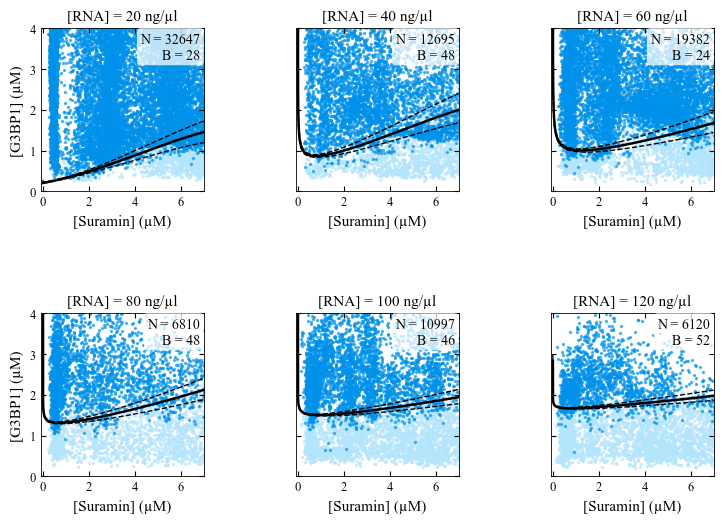

In [6]:
# --------------------------------------------------------------
# Plot
# --------------------------------------------------------------
n = nslabs
ncols = int(np.ceil(n / 2))
nrows = 2

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "font.size": 12,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 10,
    "axes.linewidth": 0.6,
    "lines.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "legend.frameon": False,
    "errorbar.capsize": 2.0,
})


panel_size = 2.8 
fig = plt.figure(figsize=(panel_size * ncols, panel_size * nrows))
axes = fig.subplots(nrows, ncols, sharey=True).flatten()

for ax in axes:
    ax.set_box_aspect(1)   # ensures square axes

xx = np.linspace(1e-8, 7, 5000)

for i, ax in enumerate(axes[:nslabs]):
    section = SECTIONS[i]
    label = section["feature"].values.astype(int)
    dil = section[label == 0]
    den = section[label == 1]

    ax.scatter(dil["Suramin"], dil["Protein"], s=2, color='#b3e5fc', alpha=0.6, rasterized=True)
    ax.scatter(den["Suramin"], den["Protein"], s=2, color='#0091ea', alpha=0.6, rasterized=True)
    
    X_plot, y_fit, yb_lo, yb_hi = get_fit_and_envelope(
    i, xx, popt, perr, model_global, lower=lower, upper=upper)

    ax.plot(xx, y_fit, color="black", lw=1.8)
    ax.plot(xx, yb_hi, color="black", ls="--", lw=1.0)
    ax.plot(xx, yb_lo, color="black", ls="--", lw=1.0)

    ax.set_xlabel("[Suramin] (µM)")
    ax.set_xlim(-0.1, 7)
    ax.set_ylim(0, 4)
    ax.set_title("[RNA] = " + names[i])

    # add counts box (upper-right)
    txt = ( f"N = {ndata_total[i]}\n"  f"B = {bcount_fit[i]}" )

    ax.text(
        0.98, 0.98, txt,
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="none", alpha=0.75),
        zorder=10
    )
    

axes[0].set_ylabel("[G3BP1] (µM)")
axes[3].set_ylabel("[G3BP1] (µM)")


plt.subplots_adjust(
    left=0.12,
    right=0.98,
    bottom=0.10,
    top=0.90,
    wspace=0.20,   # horizontal spacing
    hspace=0.75    # vertical spacing
)

plt.show()

In [7]:
def theta_free_R(R, K_D, n):
    R = np.asarray(R, dtype=float)
    return 1.0 / (1.0 + (R / K_D)**n)

# Keep names chi3_model / dchi_model for compatibility with your later code
def chi3_model(R, A, K_D, n):
    return A * theta_free_R(R, K_D, n)

def dchi_model(R, A, K_D, n):
    return A * theta_free_R(R, K_D, n)

def global_model(R_all, A, K_D, n):
    m = R_all.shape[0] // 2
    R1 = R_all[:m]
    R2 = R_all[m:2*m]
    out1 = chi3_model(R1, A, K_D, n)
    out2 = dchi_model(R2, A, K_D, n)
    return np.concatenate([out1, out2])


# Normalize to reference point: [RNA] = 20 (first entry)
def normalize_with_error(y, sy, iref=0):
    """
    Normalize y -> y/y0 with proper error propagation.
    Treat the reference point specially (ratio y0/y0=1, no √2 artifact).
    """
    y  = np.asarray(y, float)
    sy = np.asarray(sy, float)

    y0  = float(y[iref])
    sy0 = float(sy[iref])

    if (not np.isfinite(y0)) or (y0 == 0.0):
        raise ValueError("Reference value y0 is zero or non-finite; cannot normalize.")
    if (not np.isfinite(sy0)):
        raise ValueError("Reference uncertainty sy0 is non-finite; cannot normalize.")

    yn = y / y0

    rel_y  = np.where(np.isfinite(y) & (y != 0.0), sy / y, 0.0)
    rel_y0 = sy0 / y0

    syn = np.abs(yn) * np.sqrt(rel_y**2 + rel_y0**2)

    # Reference point: y=y0 is the same measurement, so ratio is exactly 1.
    # Keep a sensible uncertainty scale: fractional uncertainty of y0.
    syn[iref] = abs(rel_y0)

    return yn, syn, y0, sy0



# Normalization-uncertainty scalars rel0 = sigma(y0)/y0
def safe_rel0(y0, sy0):
    y0 = float(y0); sy0 = float(sy0)
    if (not np.isfinite(y0)) or (y0 == 0.0) or (not np.isfinite(sy0)):
        return 0.0
    return abs(sy0 / y0)


In [8]:
# Compute c(R), p(R) and proper error propagation
R = slab_values.astype(float)
KD_fit, n_fit, c0_fit, p0_fit = popt[:4]
perr = np.sqrt(np.diag(pcov))

# 4×4 covariance for (KD, n, c0, p0)
C4 = pcov[:4, :4]

# Hill function theta(R)
theta = 1.0 / (1.0 + (R / KD_fit)**n_fit)

c_vals = c0_fit * theta
p_vals = p0_fit * theta


# --------------------------------------------------------------
# derivatives for error propagation
# --------------------------------------------------------------

# d theta / d KD
dtheta_dKD = ( theta**2 * n_fit * (R / KD_fit)**n_fit / KD_fit )

# d theta / d n
dtheta_dn = ( -theta**2 * (R / KD_fit)**n_fit * np.log(R / KD_fit)  )

# c(R) derivatives wrt [KD, n, c0, p0]
dc_dKD = c0_fit * dtheta_dKD
dc_dn  = c0_fit * dtheta_dn
dc_dc0 = theta
dc_dp0 = np.zeros_like(theta)

# p(R) derivatives
dp_dKD = p0_fit * dtheta_dKD
dp_dn  = p0_fit * dtheta_dn
dp_dc0 = np.zeros_like(theta)
dp_dp0 = theta

# propagate variance: σ² = J C Jᵀ
c_err = []
p_err = []

for i in range(len(R)):
    Jc = np.array([dc_dKD[i], dc_dn[i], dc_dc0[i], dc_dp0[i]])
    Jp = np.array([dp_dKD[i], dp_dn[i], dp_dc0[i], dp_dp0[i]])

    var_c = Jc @ C4 @ Jc
    var_p = Jp @ C4 @ Jp

    c_err.append(np.sqrt(abs(var_c)))
    p_err.append(np.sqrt(abs(var_p)))

c_err = np.array(c_err)
p_err = np.array(p_err)


# --------------------------------------------------------------
# ratio r = p/c with error
# --------------------------------------------------------------
c_vals = np.asarray(c_vals, float)
c_err  = np.asarray(c_err, float)
p_vals = np.asarray(p_vals, float)
p_err  = np.asarray(p_err, float)

ratio_vals = p_vals / c_vals
ratio_err  = np.abs(ratio_vals) * np.sqrt((p_err / p_vals)**2 + (c_err / c_vals)**2)


print("\n=== c(R), p(R) with uncertainty ===")
for i in range(len(R)):
    print(
        f"RNA={R[i]:.0f}"
        f"c = {c_vals[i]:.6g} ± {c_err[i]:.3g}"
        f"p = {p_vals[i]:.6g} ± {p_err[i]:.3g}"
    )


=== c(R), p(R) with uncertainty ===
RNA=20c = 0.522682 ± 0.206p = 0.0884166 ± 0.0257
RNA=40c = 0.403371 ± 0.109p = 0.0682341 ± 0.0142
RNA=60c = 0.236349 ± 0.0625p = 0.0399807 ± 0.0119
RNA=80c = 0.125543 ± 0.027p = 0.0212367 ± 0.00629
RNA=100c = 0.0686887 ± 0.0138p = 0.0116194 ± 0.00345
RNA=120c = 0.0400798 ± 0.0119p = 0.00677989 ± 0.00247


In [9]:
# Physical quantities calculated
# L^1 = 10**3, L^3 = 100, L^{12} = 10**4
competition_vals = p_vals / (1.8*10**(-8) * 10**4 * 10)
competition_err  = p_err  / (1.8*10**(-8) * 10**4 * 10)

repulsion_vals = c_vals / (1.8*10**(-8) * 100 * 10**4 * 10**(-2) )
repulsion_err  = c_err  / (1.8*10**(-8) * 100 * 10**4 * 10**(-2) )

kd_vals = ratio_vals * 10**3  # µM
kd_err  = ratio_err  * 10**3


# normalized physical quantities
iref = 0  # the first entry

competition_n, competition_nerr, comp_ref, comp_ref_err = normalize_with_error(
    competition_vals, competition_err, iref )

repulsion_n, repulsion_nerr, rep_ref, rep_ref_err = normalize_with_error(
    repulsion_vals, repulsion_err, iref )

kd_n, kd_nerr, kd_ref, kd_ref_err = normalize_with_error(kd_vals, kd_err, iref)


rel0_chi3 = safe_rel0(rep_ref,  rep_ref_err)
rel0_dchi = safe_rel0(comp_ref, comp_ref_err)
rel0_kd   = safe_rel0(kd_ref,   kd_ref_err)

print("\n--- The raw estimation at [RNA] = 20 ng/µl ---\n")
print(f"  Δχ_ref  = {comp_ref:.6g} ± {comp_ref_err:.6g}")
print(f"  χ3_ref  = {rep_ref:.6g} ± {rep_ref_err:.6g}")
print(f"  Kd_ref  = {kd_ref:.6g} ± {kd_ref_err:.6g} µM")
print(f"  rel0 (χ3, Δχ, Kd) =", rel0_chi3, rel0_dchi, rel0_kd)


# --------------------------------------------------------------
# Print results
# --------------------------------------------------------------
print("\n--- Normalized Physica Quantities to [RNA] = 20 ng/µl ---\n")
for i in range(len(competition_n)):
    print(
        f"[RNA] = {R[i]:.0f} ng/µl : χ3_0 = {repulsion_n[i]:.3g} ± {repulsion_nerr[i]:.3g},  "
        f"Δχ_0 = {competition_n[i]:.3g} ± {competition_nerr[i]:.3g} , Kd_0 = {kd_n[i]:.3g} ± {kd_nerr[i]:.3g}"
    )
    print()

    


--- The raw estimation at [RNA] = 20 ng/µl ---

  Δχ_ref  = 49.1204 ± 14.2786
  χ3_ref  = 2903.79 ± 1146.15
  Kd_ref  = 169.16 ± 82.9216 µM
  rel0 (χ3, Δχ, Kd) = 0.3947089109886173 0.29068592490627826 0.49019733919355235

--- Normalized Physica Quantities to [RNA] = 20 ng/µl ---

[RNA] = 20 ng/µl : χ3_0 = 1 ± 0.395,  Δχ_0 = 1 ± 0.291 , Kd_0 = 1 ± 0.49

[RNA] = 40 ng/µl : χ3_0 = 0.772 ± 0.369,  Δχ_0 = 0.772 ± 0.276 , Kd_0 = 1 ± 0.597

[RNA] = 60 ng/µl : χ3_0 = 0.452 ± 0.215,  Δχ_0 = 0.452 ± 0.188 , Kd_0 = 1 ± 0.631

[RNA] = 80 ng/µl : χ3_0 = 0.24 ± 0.108,  Δχ_0 = 0.24 ± 0.0997 , Kd_0 = 1 ± 0.612

[RNA] = 100 ng/µl : χ3_0 = 0.131 ± 0.0582,  Δχ_0 = 0.131 ± 0.0546 , Kd_0 = 1 ± 0.607

[RNA] = 120 ng/µl : χ3_0 = 0.0767 ± 0.0378,  Δχ_0 = 0.0767 ± 0.0358 , Kd_0 = 1 ± 0.679



In [10]:
# Hill function plot and envelope


# --------------------------------------------------------------
# x-axis: RNA slabs x_array
# --------------------------------------------------------------
x = np.asarray(slab_values, dtype=float)
x_ref = float(x[0])  # reference slab (RNA = 20)

# --------------------------------------------------------------
# Smooth grids
# --------------------------------------------------------------
x_fit_n = np.linspace(0.1, 140.0, 600)

# a shorter x_fit array
x_fit_s_n = np.linspace(float(np.min(x)), 140.0, 600)

# covariance sub-block for (K_D, n) from global boundary fit
C_Kn = pcov[np.ix_([0, 1], [0, 1])]

# --------------------------------------------------------------
# Central normalized Hill prediction:
#   y_n(R) = theta_free_R(R) / theta_free_R(R_ref)
# --------------------------------------------------------------
theta_fit = theta_free_R(x_fit_n, KD_fit, n_fit)
theta_ref = float(theta_free_R(np.array([x_ref]), KD_fit, n_fit)[0])
yfit_n = theta_fit / theta_ref   # Hill function curve also normalized

# Both three-body repulsion and competition described by this yfit_ratio
yfit_chi3_n = yfit_n
yfit_dchi_n = yfit_n

# --------------------------------------------------------------
# Normalized Kd prediction: constant = 1
# --------------------------------------------------------------
yfit_kd_n = np.ones_like(x_fit_n, dtype=float)

# Dashed envelope for normalized Kd:
# use the reference fractional uncertainty rel0_kd,
# so the band is 1 ± rel0_kd everywhere
ylo_kd_n = (1.0 - rel0_kd) * np.ones_like(x_fit_n, dtype=float)
yhi_kd_n = (1.0 + rel0_kd) * np.ones_like(x_fit_n, dtype=float)


# ==============================================================
#  Curve and total envelope for normalized Hill curve
#  f(R) = theta_free_R(R, K_D, n) / theta_free_R(R_ref, K_D, n)
# ==============================================================
def envelope_normalized( Rgrid, R_ref, K_D, n, C_Kn, rel0=0.0, nsigma=1.0, nsamp=6000, seed=1, tol=1e-12,):
    
    Rgrid = np.asarray(Rgrid, dtype=float)
    R_ref = float(R_ref)
    C_Kn = np.asarray(C_Kn, dtype=float)

    if C_Kn.shape != (2, 2) or not np.all(np.isfinite(C_Kn)):
        raise ValueError("C_Kn must be a finite 2x2 covariance matrix for (K_D, n).")

    use_norm_error = (rel0 is not None) and (float(rel0) != 0.0)

    # Central curve
    theta_ref0 = float(theta_free_R([R_ref], K_D, n)[0])
    f0 = theta_free_R(Rgrid, K_D, n) / theta_ref0

    # Convert nsigma to central Gaussian percentile interval
    alpha = 0.5 * (1.0 - np.math.erf(float(nsigma) / np.sqrt(2.0)))
    plo = 100.0 * alpha
    phi = 100.0 * (1.0 - alpha)
    
    # Monte Carlo sampling of (K_D, n)
    rng = np.random.default_rng(seed)
    samp = rng.multivariate_normal([float(K_D), float(n)], C_Kn, size=int(nsamp), )

    Ks = np.clip(samp[:, 0], 1e-15, np.inf)
    ns = np.clip(samp[:, 1], 1e-12, np.inf)

    # Evaluate sampled ratio curves
    theta_num = theta_free_R(Rgrid[None, :], Ks[:, None], ns[:, None])
    theta_den = theta_free_R(np.array([[R_ref]]), Ks[:, None], ns[:, None])
    Ys = theta_num / theta_den

    # parameter-only envelope from percentiles
    ylo_p = np.percentile(Ys, plo, axis=0)
    yhi_p = np.percentile(Ys, phi, axis=0)

    # Add optional normalization uncertainty in quadrature
    if use_norm_error:
        sig_param = 0.5 * (yhi_p - ylo_p)
        sig_norm = abs(float(rel0)) * f0
        sig_tot = np.sqrt(sig_param**2 + sig_norm**2)

        ylo = f0 - float(nsigma) * sig_tot
        yhi = f0 + float(nsigma) * sig_tot
    else:
        ylo = ylo_p
        yhi = yhi_p

    # Enforce exact behavior at reference if R_ref is on grid
    idx = int(np.argmin(np.abs(Rgrid - R_ref)))
    if abs(Rgrid[idx] - R_ref) <= tol:
        if use_norm_error:
            ylo[idx] = 1.0 - float(nsigma) * abs(float(rel0))
            yhi[idx] = 1.0 + float(nsigma) * abs(float(rel0))
        else:
            ylo[idx] = 1.0
            yhi[idx] = 1.0

    return ylo, yhi


# --------------------------------------------------------------
# Envelopes including normalization uncertainty
# --------------------------------------------------------------
ylo_chi3_n, yhi_chi3_n = envelope_normalized(
    x_fit_s_n, x_ref, KD_fit, n_fit, C_Kn, rel0=rel0_chi3, nsigma=1.0
)

ylo_dchi_n, yhi_dchi_n = envelope_normalized(
    x_fit_s_n, x_ref, KD_fit, n_fit, C_Kn, rel0=rel0_dchi, nsigma=1.0
)


# --------------------------------------------------------------
# Fitted normalized Kd_n to a constant (weighted mean) + 1σ band
# --------------------------------------------------------------
w = 1.0 / np.clip(kd_nerr, 1e-15, np.inf)**2
Kd_const = np.sum(w * kd_n) / np.sum(w)
Kd_const_err = np.sqrt(1.0 / np.sum(w))

yfit_kd_n = Kd_const * np.ones_like(x_fit_n)
ylo_kd_n = (Kd_const - Kd_const_err) * np.ones_like(x_fit_n)
yhi_kd_n = (Kd_const + Kd_const_err) * np.ones_like(x_fit_n)

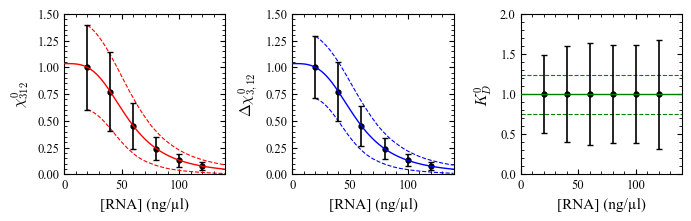

In [11]:
# -------------------------------
# Plot Fig. 4(b)
# -------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "cm",
    "font.size": 10,
    "axes.linewidth": 0.8,
    "axes.labelsize": 11,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "legend.frameon": False,
    "errorbar.capsize": 2.5,
})

fig, axes = plt.subplots(1, 3, figsize=(6.8, 2.1))

# normalized chi3 vs RNA
axes[0].errorbar(x, repulsion_n, yerr=repulsion_nerr, fmt='o', color='k', ms=3.5, zorder=3)
axes[0].plot(x_fit_n, yfit_chi3_n, '-', color='r', lw=1.0, zorder=4)
axes[0].plot(x_fit_s_n, ylo_chi3_n,  '--', color='r', lw=0.8)
axes[0].plot(x_fit_s_n, yhi_chi3_n,  '--', color='r', lw=0.8)
axes[0].set_xlabel("[RNA] (ng/µl)")
axes[0].set_ylabel(r"$\chi^{0}_{312}$")
axes[0].minorticks_on()
axes[0].set_xlim(0, 140)
axes[0].set_ylim(0, 1.5)
axes[0].tick_params(which='both', direction='in')

# normalized dchi vs RNA
axes[1].errorbar(x, competition_n, yerr=competition_nerr, fmt='o', color='k', ms=3.5, zorder=3)
axes[1].plot(x_fit_n, yfit_dchi_n, '-', color='b', lw=1.0, zorder=4)
axes[1].plot(x_fit_s_n, ylo_dchi_n,  '--', color='b', lw=0.8)
axes[1].plot(x_fit_s_n, yhi_dchi_n,  '--', color='b', lw=0.8)
axes[1].set_xlabel("[RNA] (ng/µl)")
axes[1].set_ylabel(r"$\Delta\chi^{0}_{3,12}$")
axes[1].minorticks_on()
axes[1].set_xlim(0, 140)
axes[1].set_ylim(0, 1.5)
axes[1].tick_params(which='both', direction='in')

# normalized Kd vs RNA (constant)
axes[2].errorbar(x, kd_n, yerr=kd_nerr, fmt='o', color='k', ms=3.5, zorder=3)
axes[2].plot(x_fit_n, yfit_kd_n, '-', color='g', lw=1.0, zorder=4)
axes[2].plot(x_fit_n, ylo_kd_n, '--', color='g', lw=0.8)
axes[2].plot(x_fit_n, yhi_kd_n, '--', color='g', lw=0.8)
axes[2].set_xlabel("[RNA] (ng/µl)")
axes[2].set_ylabel(r"$K^{0}_{D}$")
axes[2].minorticks_on()
axes[2].set_xlim(0, 140)
axes[2].set_ylim(0, 2.0)
axes[2].tick_params(which='both', direction='in')

plt.tight_layout(pad=0.3, w_pad=0.8)
plt.show()

In [12]:
# --------------------------------------
# Hill linearization for Hill function:
# y_n(R) = theta(R)/theta(R_ref)
# --------------------------------------
def hill_normalized_linearized(R, y_n, yerr_n, R_ref, K, n,
                              ymin_clip=-6.0,
                              cap_dY=4.0):
    """
    Exact Hill-linear transform

    Y = ln(A / y_n - 1)
    A = 1/theta(R_ref) = 1 + (R_ref/K)^n

    """

    R = np.asarray(R, float)
    y = np.asarray(y_n, float)
    sy = np.asarray(yerr_n, float)

    # Only require R>0 and finite
    base = np.isfinite(R) & np.isfinite(y) & np.isfinite(sy) & (R > 0) & (y > 0)

    Rg, yg, sg = R[base], y[base], sy[base]
    X = np.log(Rg)

    # Compute A from fitted parameters
    A = 1.0 + (R_ref / K)**n

    # g must be positive
    g = (A / yg) - 1.0

    Y = np.empty_like(g)

    mask_reg = g > 0
    Y[mask_reg] = np.log(g[mask_reg])

    # asymptote (if yg extremely close to A)
    mask_asym = ~mask_reg
    Y[mask_asym] = ymin_clip

    # derivative:
    # Y = ln(A/y - 1)
    # dY/dy = -A / [ y (A - y) ]
    denom = yg * (A - yg)
    dY_dy = -A / denom

    dY = np.zeros_like(Y)
    dY[mask_reg] = np.abs(dY_dy[mask_reg]) * sg[mask_reg]

    # small error for asymptote points
    dY[mask_asym] = 0.1

    if cap_dY is not None:
        dY = np.minimum(dY, cap_dY)

    return X, Y, dY, A



# ----------------------------------------------------------
# Envelope for Hill line Y = n ln R - n ln K given cov(K,n)
# ----------------------------------------------------------
def hill_linearized_envelope(x, K_mean, n_mean, cov_Kn,
                          nsamp=4000, pct=(16,84), seed=1):

    rng = np.random.default_rng(seed)
    samp = rng.multivariate_normal([K_mean, n_mean], cov_Kn, size=nsamp)

    Ks = np.clip(samp[:,0], 1e-15, np.inf)
    ns = np.clip(samp[:,1], 1e-12, np.inf)

    Ys = (ns[:,None] * x[None,:]) - (ns[:,None] * np.log(Ks)[:,None])

    y_med = np.percentile(Ys, 50, axis=0)
    y_lo  = np.percentile(Ys, pct[0], axis=0)
    y_hi  = np.percentile(Ys, pct[1], axis=0)

    return y_med, y_lo, y_hi


# ------------------------
# Hill transform the data
# ------------------------
x = np.asarray(slab_values, float)
x_ref = float(x[0])

cov_Kn = pcov[np.ix_([0,1],[0,1])]
K_hill = float(KD_fit)
n_hill = float(n_fit)

# Linearize χ3 and Δχ
X1, Y1, dY1, A1 = hill_normalized_linearized(
    x, repulsion_n, repulsion_nerr,
    R_ref=x_ref, K=K_hill, n=n_hill
)

X2, Y2, dY2, A2 = hill_normalized_linearized(
    x, competition_n, competition_nerr,
    R_ref=x_ref, K=K_hill, n=n_hill
)


# Print the prefactor A (approximatedly the intrapolated [RNA] = 0 data)
print("A (χ3) =", A1)
print("A (Δχ) =", A2)

# Line grid
xmin_pos = np.min(x[x > 0])
R_line = np.linspace(0.9*xmin_pos, 1.2*np.max(x), 800)
X_line = np.log(R_line)

Y_med, Y_lo, Y_hi = hill_linearized_envelope( X_line, K_hill, n_hill, cov_Kn )




A (χ3) = 1.0352159288437222
A (Δχ) = 1.0352159288437222


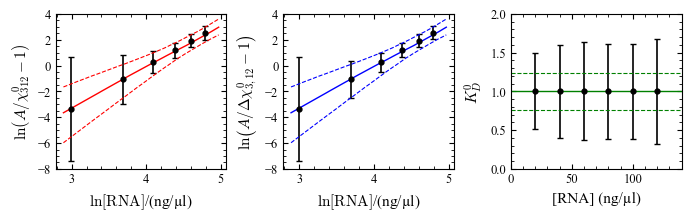

In [13]:
# ---------------
# Plot Fig. 2(c)
# ---------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "cm",
    "font.size": 10,
    "axes.linewidth": 0.8,
    "axes.labelsize": 11,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "legend.frameon": False,
    "errorbar.capsize": 2.5,
})

fig, axes = plt.subplots(1, 3, figsize=(6.8, 2.1))

# (a) Hill plot for chi3_n (normalized)
axes[0].errorbar(X1, Y1, yerr=dY1, fmt='o', color='k', ms=3.5)
axes[0].plot(X_line, Y_med, '-',  color='r', lw=1.0)
axes[0].plot(X_line, Y_lo,  '--', color='r', lw=0.8)
axes[0].plot(X_line, Y_hi,  '--', color='r', lw=0.8)
axes[0].set_xlabel(r"$\ln[\mathrm{RNA}]$/(ng/µl)")
axes[0].set_ylabel(r"$\ln\!\left(A/\chi^{0}_{312} -1\right)$")
axes[0].set_ylim(-8, 4)
axes[0].minorticks_on()
axes[0].tick_params(which='both', direction='in')

# (b) Hill plot for dchi_n (normalized)
axes[1].errorbar(X2, Y2, yerr=dY2, fmt='o', color='k', ms=3.5)
axes[1].plot(X_line, Y_med, '-',  color='b', lw=1.0)
axes[1].plot(X_line, Y_lo,  '--', color='b', lw=0.8)
axes[1].plot(X_line, Y_hi,  '--', color='b', lw=0.8)
axes[1].set_xlabel(r"$\ln[\mathrm{RNA}]$/(ng/µl)")
axes[1].set_ylabel(r"$\ln\!\left(A/\Delta\chi^{0}_{3,12} -1\right)$")
axes[1].set_ylim(-8, 4)
axes[1].minorticks_on()
axes[1].tick_params(which='both', direction='in')

# (c) K_D^0 normalized constant fit
axes[2].errorbar(x, kd_n, yerr=kd_nerr, fmt='o', color='k', ms=3.5)
axes[2].plot(x_fit_n, yfit_kd_n, '-',  color='g', lw=1.0)
axes[2].plot(x_fit_n, ylo_kd_n, '--', color='g', lw=0.8)
axes[2].plot(x_fit_n, yhi_kd_n, '--', color='g', lw=0.8)
axes[2].set_xlabel("[RNA] (ng/µl)")
axes[2].set_ylabel(r"$K_D^0$")
axes[2].minorticks_on()
axes[2].set_xlim(0, 140)
axes[2].set_ylim(0, 2)
axes[2].tick_params(which='both', direction='in')

plt.tight_layout(pad=0.3, w_pad=0.6)
plt.show()

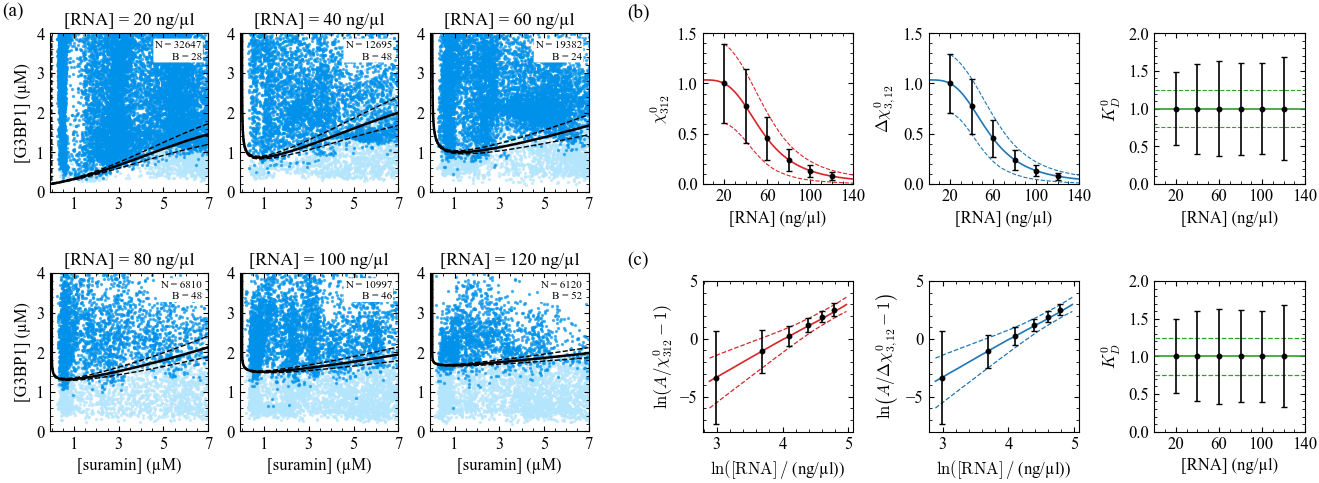

In [14]:
# ---------------
# Plot Fig. 4
# ---------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Nimbus Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "axes.linewidth": 0.8,

    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,

    "legend.frameon": False,
    "lines.linewidth": 1.2,
    "errorbar.capsize": 2.5,

    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})

plt.rcParams["pdf.compression"] = 0
plt.rcParams["path.simplify"] = False
plt.rcParams["agg.path.chunksize"] = 0

def apply_ticks(ax):
    ax.minorticks_on()
    ax.tick_params(which="both", direction="in", top=True, right=True)

def subfig_label(ax, text, x=-0.28, y=1.12, fontsize=11, bold=False):
    ax.text(
        x, y, text,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=fontsize,
        fontweight="bold" if bold else "normal"
    )

if "rel0_chi3" not in globals():
    rel0_chi3 = _safe_rel0(rep_ref, rep_ref_err)
if "rel0_dchi" not in globals():
    rel0_dchi = _safe_rel0(comp_ref, comp_ref_err)
if "rel0_kd" not in globals():
    rel0_kd   = _safe_rel0(kd_ref, kd_ref_err)

# ----------------
# Layout Control
# ----------------
n = int(nslabs)
ncols_a = 3
nrows_a = int(np.ceil(n / ncols_a))

AX_A = 2.0
WSPACE_A = 0.20
HSPACE_A = 0.25

WSPACE_R = 0.50
HSPACE_R = 0.35

MLEFT, MRIGHT, MBOTTOM, MTOP = 0.85, 0.25, 0.70, 0.40
GUTTER = 0.70

gapA_w = WSPACE_A * AX_A
gapA_h = HSPACE_A * AX_A
W_left = ncols_a * AX_A + (ncols_a - 1) * gapA_w
H_left = nrows_a * AX_A + (nrows_a - 1) * gapA_h

gapR_h = HSPACE_R * AX_A
AX_R = (H_left - gapR_h) / 2.0
if AX_R <= 0:
    raise ValueError("H_left too small. Reduce HSPACE_R or increase AX_A.")

gapR_w = WSPACE_R * AX_R
W_right = 3 * AX_R + 2 * gapR_w

FIG_W = MLEFT + W_left + GUTTER + W_right + MRIGHT
FIG_H = MBOTTOM + H_left + MTOP

fig = plt.figure(figsize=(FIG_W, FIG_H))
gs = GridSpec(1, 2, figure=fig, width_ratios=[W_left, W_right], wspace=0.20)
gs_r = gs[1].subgridspec(2, 1, hspace=HSPACE_R)



# ----------------------------------------------------------
# Fig. 4(a) LEFT: GLOBAL fit phase boundary curves
# ----------------------------------------------------------
gs_a = gs[0].subgridspec(nrows_a, ncols_a, wspace=WSPACE_A, hspace=HSPACE_A)
axes_a = np.array([fig.add_subplot(gs_a[r, c]) for r in range(nrows_a) for c in range(ncols_a)])
subfig_label(axes_a[0], "(a)", x=-0.30, y=1.20, bold=False, fontsize=14)


xx1 = np.logspace(-200, -11, 5000)
xx2 = np.linspace(1e-10, 7, 3000)
xx = np.concatenate((xx1, xx2))


for i, ax in enumerate(axes_a[:nslabs]):
    section = SECTIONS[i]
    label = section["feature"].values.astype(int)
    dil = section[label == 0]
    den = section[label == 1]

    ax.scatter(dil["Suramin"], dil["Protein"], s=2, color='#b3e5fc', alpha=0.6, rasterized=True)
    ax.scatter(den["Suramin"], den["Protein"], s=2, color='#0091ea', alpha=0.6, rasterized=True)
    
    X_plot, y_fit, yb_lo, yb_hi = get_fit_and_envelope(
    i, xx, popt, perr, model_global, lower=lower, upper=upper)

    ax.plot(xx, y_fit, color="black", lw=1.8)
    ax.plot(xx, yb_hi, color="black", ls="--", lw=1.0)
    ax.plot(xx, yb_lo, color="black", ls="--", lw=1.0)

    ax.set_xlim(-0.1, 7)
    ax.set_ylim(0, 4)
    ax.set_xticks([1.0,3.0,5.0,7.0])   
    ax.set_xlabel("[suramin] (µM)")
    ax.set_title(f"[RNA] = {names[i]}")
    
    if i % 3 == 0:
        ax.set_ylabel("[G3BP1] (µM)")
    else:
        ax.set_ylabel("")
    if i >= 3:
        ax.set_xlabel("[suramin] (µM)")
    else:
        ax.set_xlabel("")

    # add counts box (upper-right)
    txt = ( f"N = {ndata_total[i]}\n" f"B = {bcount_fit[i]}" )
    
    ax.text(
        0.96, 0.96, txt,
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.1", facecolor="white", edgecolor="none", alpha=1.0),
        zorder=10
    )

for ax in axes_a:
    apply_ticks(ax)
    ax.set_box_aspect(1)



# ----------------------------------------------------------
# Fig. 4(b) TOP-RIGHT: normalized physical quantities vs RNA
# ----------------------------------------------------------
gs_b = gs_r[0].subgridspec(1, 3, wspace=WSPACE_R)
axes_b = [fig.add_subplot(gs_b[0, j]) for j in range(3)]
subfig_label(axes_b[0], "(b)", x=-0.50, y=1.20, bold=False, fontsize=14)

# χ3 normalized 
axes_b[0].errorbar(x, repulsion_n, yerr=repulsion_nerr, fmt="o", color="k", ms=3.2, zorder=3)
axes_b[0].plot(x_fit_n, yfit_chi3_n, "-", color="tab:red", lw=1.2, zorder=2)
axes_b[0].plot(x_fit_s_n, ylo_chi3_n,  '--', color='tab:red', lw=0.8)
axes_b[0].plot(x_fit_s_n, yhi_chi3_n,  '--', color='tab:red', lw=0.8)
axes_b[0].set_xlabel("[RNA] (ng/µl)")
axes_b[0].set_ylabel(r"$\chi^{0}_{312}$")
axes_b[0].set_xticks([20,60,100,140])
axes_b[0].set_xlim(0, 140)
axes_b[0].set_ylim(0, 1.5)

# Δχ normalized 
axes_b[1].errorbar(x, competition_n, yerr=competition_nerr, fmt="o", color="k", ms=3.2, zorder=3)
axes_b[1].plot(x_fit_n, yfit_dchi_n, "-", color="tab:blue", lw=1.2, zorder=2)
axes_b[1].plot(x_fit_s_n, ylo_dchi_n,  '--', color='tab:blue', lw=0.8)
axes_b[1].plot(x_fit_s_n, yhi_dchi_n,  '--', color='tab:blue', lw=0.8)
axes_b[1].set_xlabel("[RNA] (ng/µl)")
axes_b[1].set_ylabel(r"$\Delta\chi^{0}_{3,12}$")
axes_b[1].set_xticks([20,60,100,140])
axes_b[1].set_xlim(0, 140)
axes_b[1].set_ylim(0, 1.5)

# K_D^0 constant
axes_b[2].errorbar(x, kd_n, yerr=kd_nerr, fmt="o", color="k", ms=3.2, zorder=3)
axes_b[2].plot(x_fit_n, yfit_kd_n, "-", color="tab:green", lw=1.2, zorder=2)
axes_b[2].plot(x_fit_n, ylo_kd_n, '--', color='tab:green', lw=0.8)
axes_b[2].plot(x_fit_n, yhi_kd_n, '--', color='tab:green', lw=0.8)
axes_b[2].set_xlabel("[RNA] (ng/µl)")
axes_b[2].set_ylabel(r"$K^{0}_{D}$")
axes_b[2].set_xticks([20,60,100,140])
axes_b[2].set_xlim(0, 140)
axes_b[2].set_ylim(0, 2)



for ax in axes_b:
    apply_ticks(ax)
    ax.set_box_aspect(1)

# ----------------------------------------------------------------
#Fig. 4 (c) BOTTOM-RIGHT: Hill-linearized panels + KD constant fit
# ----------------------------------------------------------------
gs_c = gs_r[1].subgridspec(1, 3, wspace=WSPACE_R)
axes_c = [fig.add_subplot(gs_c[0, j]) for j in range(3)]
subfig_label(axes_c[0], "(c)", x=-0.50, y=1.20, bold=False, fontsize=14)

# χ3 linearized
axes_c[0].errorbar(X1, Y1, yerr=dY1, fmt="o", color="k", ms=3.2, zorder=3)
axes_c[0].plot(X_line, Y_med, "-",  color="tab:red", lw=1.2, zorder=2)
axes_c[0].plot(X_line, Y_lo,  "--", color="tab:red", lw=0.9, zorder=2)
axes_c[0].plot(X_line, Y_hi,  "--", color="tab:red", lw=0.9, zorder=2)
axes_c[0].set_xlabel(r"$\ln([\mathrm{RNA}]\,/$ (ng/µl))")
axes_c[0].set_ylabel(r"$\ln\!\left(A/\chi^{0}_{312}-1\right)$")
#axes_c[0].set_xlim(0, 5)
axes_c[0].set_ylim(-8, 5)

# Δχ linearized
axes_c[1].errorbar(X2, Y2, yerr=dY2, fmt="o", color="k", ms=3.2, zorder=3)
axes_c[1].plot(X_line, Y_med, "-",  color="tab:blue", lw=1.2, zorder=2)
axes_c[1].plot(X_line, Y_lo,  "--", color="tab:blue", lw=0.9, zorder=2)
axes_c[1].plot(X_line, Y_hi,  "--", color="tab:blue", lw=0.9, zorder=2)
axes_c[1].set_xlabel(r"$\ln([\mathrm{RNA}]\,/$ (ng/µl))")
axes_c[1].set_ylabel(r"$\ln\!\left(A/\Delta\chi^{0}_{3,12}-1\right)$")
#axes_c[1].set_xlim(0, 5)
axes_c[1].set_ylim(-8, 5)

# K_D^0 constant
axes_c[2].errorbar(x, kd_n, yerr=kd_nerr, fmt="o", color="k", ms=3.2, zorder=3)
axes_c[2].plot(x_fit_n, yfit_kd_n, "-",  color="tab:green", lw=1.2, zorder=2)
axes_c[2].plot(x_fit_n, ylo_kd_n, "--", color="tab:green", lw=0.9, zorder=2)
axes_c[2].plot(x_fit_n, yhi_kd_n, "--", color="tab:green", lw=0.9, zorder=2)
axes_c[2].set_xlabel("[RNA] (ng/µl)")
axes_c[2].set_ylabel(r"$K^{0}_{D}$")
axes_c[2].set_xticks([20,60,100,140])
axes_c[2].set_xlim(0, 140)
axes_c[2].set_ylim(0, 2)

for ax in axes_c:
    apply_ticks(ax)
    ax.set_box_aspect(1)
    
    
    

# ==============================================================
# Export
# ==============================================================
#fig.savefig("Figure_4.pdf")
#fig.savefig("Figure_4.png", dpi=600)
plt.show()